In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110


##  Loading Data

In [3]:
column_names = [
    "age", "workclass", "fnlwgt", "education", "education_num",
    "marital_status", "occupation", "relationship", "race", "sex",
    "capital_gain", "capital_loss", "hours_per_week", "native_country", "income"
]

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/adult-all.csv"
df = pd.read_csv(url, header=None, names=column_names, na_values=["?"], skipinitialspace=True)

print(df.shape)
df.head()


(48842, 15)


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


##  Data Cleaning

In [7]:
# strip whitespace from text columns
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].str.strip()

print("Duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)
print("Shape after cleaning:", df.shape)

Duplicate rows: 0
Shape after cleaning: (48790, 15)


C:\Users\User\AppData\Local\Temp\ipykernel_9192\2663480219.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object").columns:


## Missing Value Handling

The `?` values were already converted to `NaN` when loading.


In [27]:
print(df.isnull().sum()[df.isnull().sum() > 0])
print('\nTotal missing values : ', df.isnull().sum().sum())

workclass         2795
occupation        2805
native_country     856
dtype: int64

Total missing values :  6456


Three columns have missing values, all around ` 8% `.
Since it's a small percentage and these are categorical columns, we'll fill them with ` mode ` the rather than dropping rows.


In [33]:
for col in ["workclass", "occupation", "native_country"]:
    df[col] = df[col].fillna(df[col].mode()[0])

print("Total Missing values left:", df.isnull().sum().sum())


Total Missing values left: 0


In [35]:
df['income'].value_counts()

income
<=50K    37109
>50K     11681
Name: count, dtype: int64

In [36]:
# make a simple 0/1 version of the target for easy plotting
df["income_binary"] = (df["income"] == ">50K").astype(int)

num_cols = ["age", "fnlwgt", "education_num", "capital_gain", "capital_loss", "hours_per_week"]
cat_cols = ["workclass", "education", "marital_status", "occupation", "relationship", "race", "sex"]


##  Feature Analysis

In [ ]:
df[num_cols].describe()

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
count,48790.000000,4.879000e+04,48790.000000,48790.000000,48790.000000,48790.000000
mean,38.652798,1.896690e+05,10.078807,1080.217688,87.595573,40.425886
std,13.708493,1.056172e+05,2.570046,7455.905921,403.209129,12.392729
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175550e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781385e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376062e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


In [ ]:
df["income"].value_counts()

income
<=50K    37109
>50K     11681
Name: count, dtype: int64

The target is imbalanced — majority of the people earn <=50K

## Visualization

### Target distribution

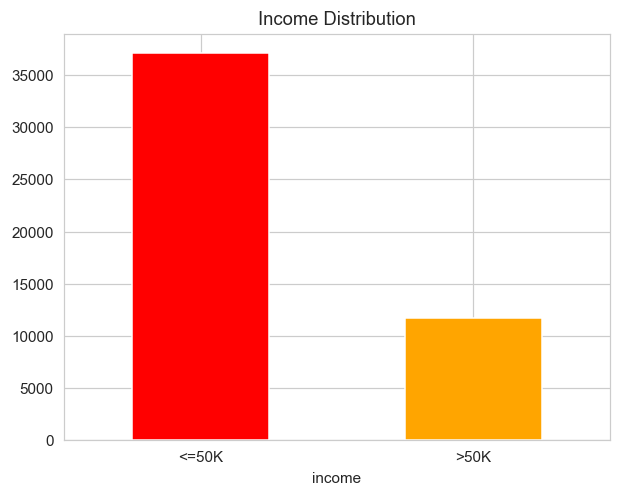

In [60]:
df["income"].value_counts().plot(kind="bar", color=["red","orange"])
plt.title("Income Distribution")
plt.xticks(rotation=0)
plt.show()


### Numeric feature distributions

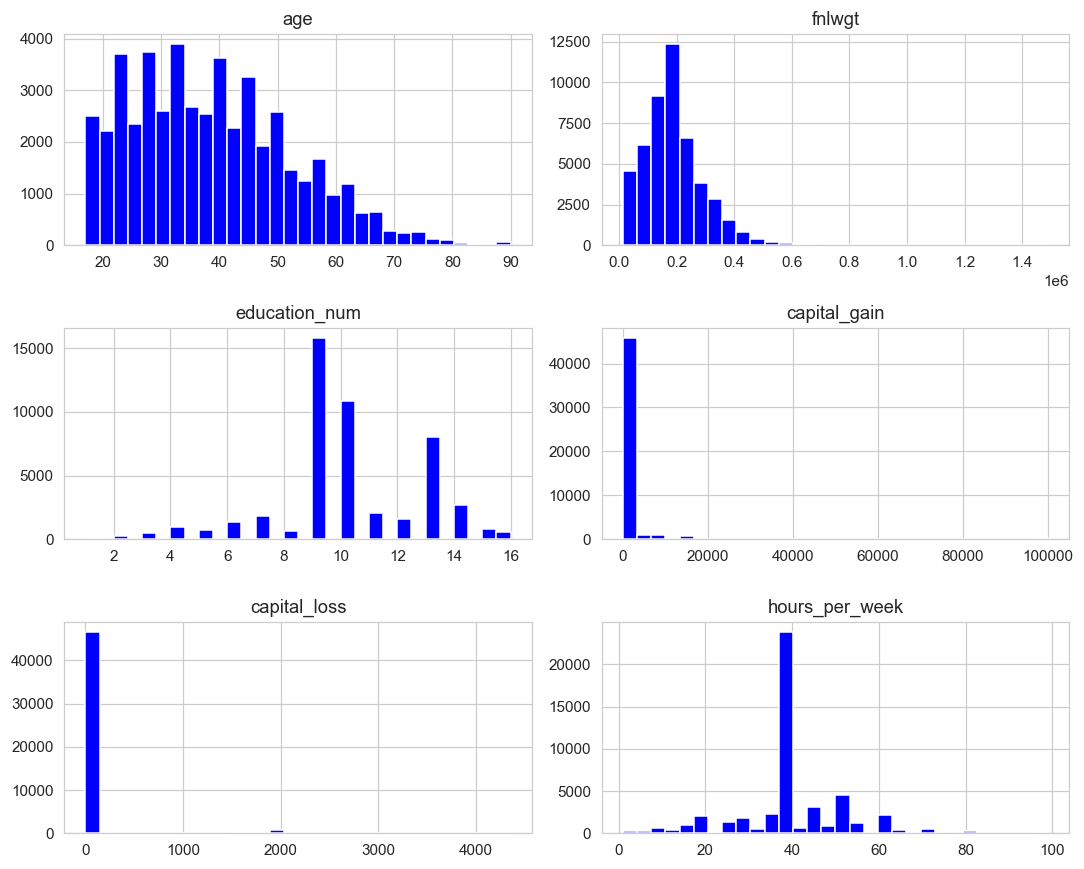

In [77]:
df[num_cols].hist(figsize=(10,8), bins=30, color="blue")
plt.tight_layout()
plt.show()

### Numeric features vs income

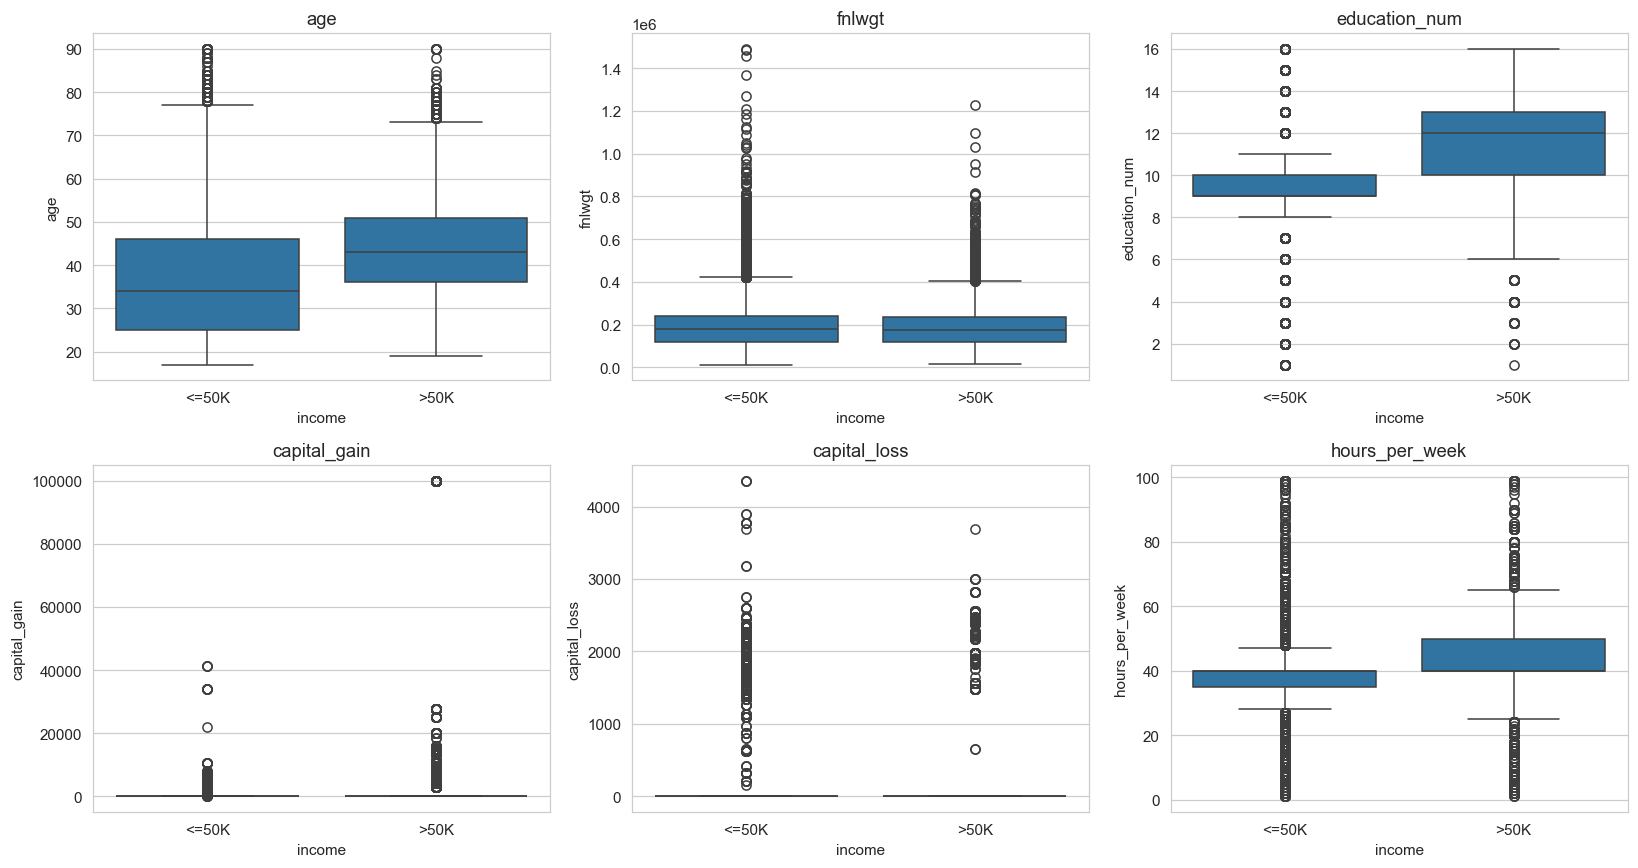

In [78]:
fig, axes = plt.subplots(2, 3, figsize=(15,8))
for ax, col in zip(axes.flat, num_cols):
    sns.boxplot(data=df, x="income", y=col, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()


### Categorical features vs income

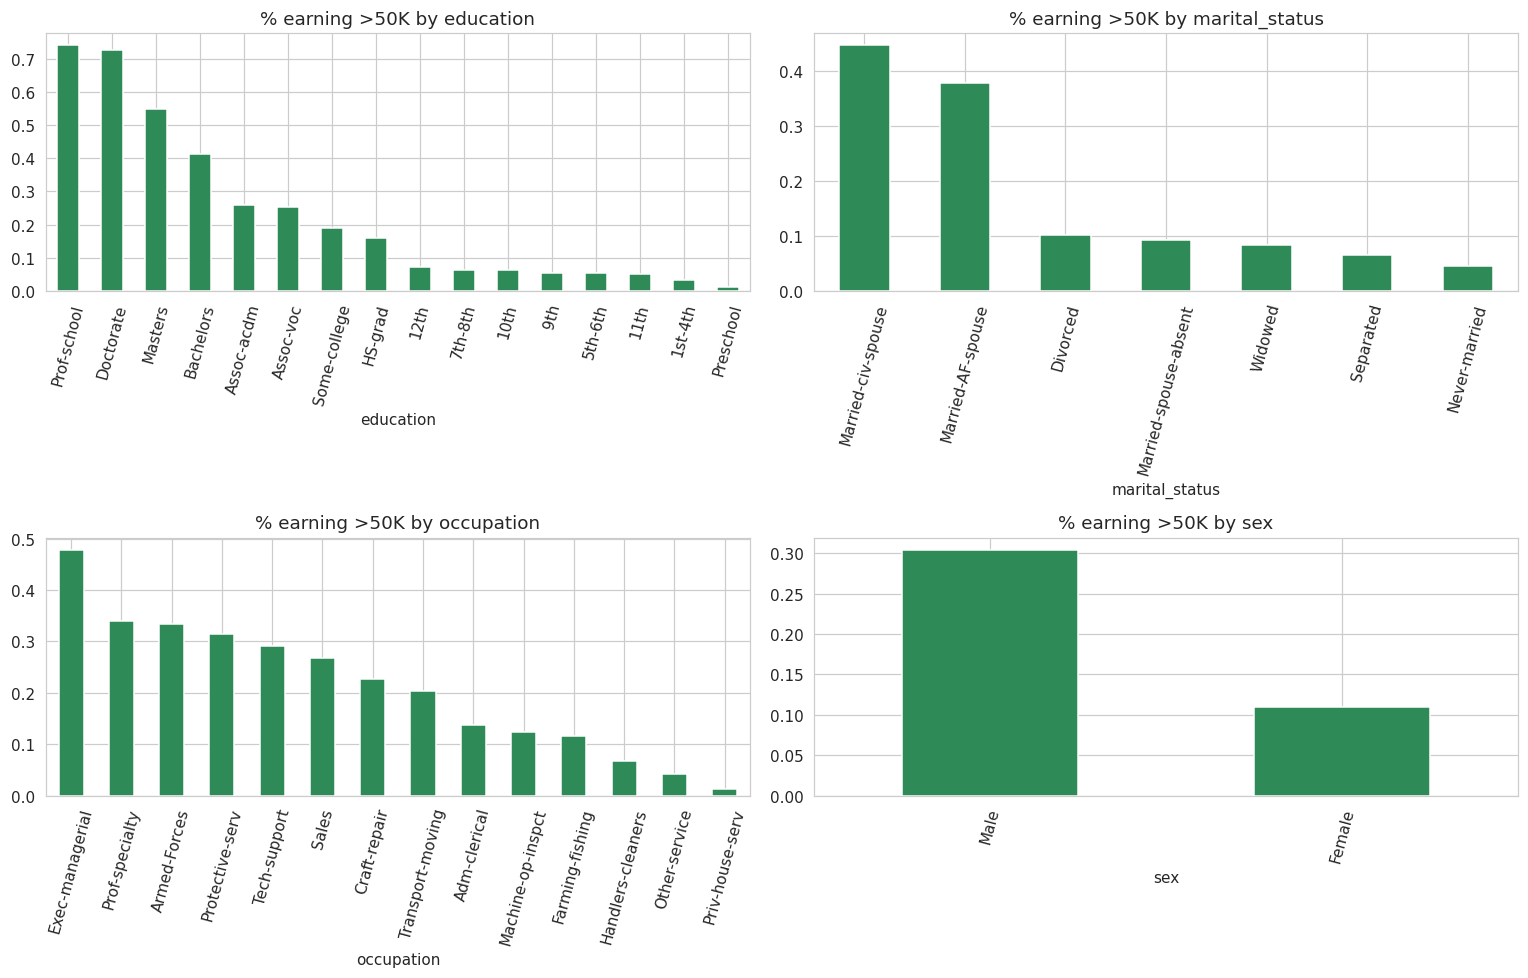

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14,9))
for ax, col in zip(axes.flat, ["education", "marital_status", "occupation", "sex"]):
    rate = df.groupby(col)["income_binary"].mean().sort_values(ascending=False)
    rate.plot(kind="bar", ax=ax, color="seagreen")
    ax.set_title(f"% earning >50K by {col}")
    ax.tick_params(axis="x", rotation=75)
plt.tight_layout()
plt.show()


## Correlation Analysis

For numeric columns we can use a standard correlation matrix.income_binary is included so we can see how each numeric feature relates to income directly.


In [80]:
df[num_cols + ["income_binary"]].corr()

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week,income_binary
age,1.000000,-0.076451,0.030635,0.077185,0.056838,0.071223,0.230144
fnlwgt,-0.076451,1.000000,-0.038727,-0.003715,-0.004378,-0.013521,-0.006309
education_num,0.030635,-0.038727,1.000000,0.125219,0.080986,0.143915,0.332802
capital_gain,0.077185,-0.003715,0.125219,1.000000,-0.031475,0.082152,0.223047
capital_loss,0.056838,-0.004378,0.080986,-0.031475,1.000000,0.054431,0.147542
hours_per_week,0.071223,-0.013521,0.143915,0.082152,0.054431,1.000000,0.227664
income_binary,0.230144,-0.006309,0.332802,0.223047,0.147542,0.227664,1.000000


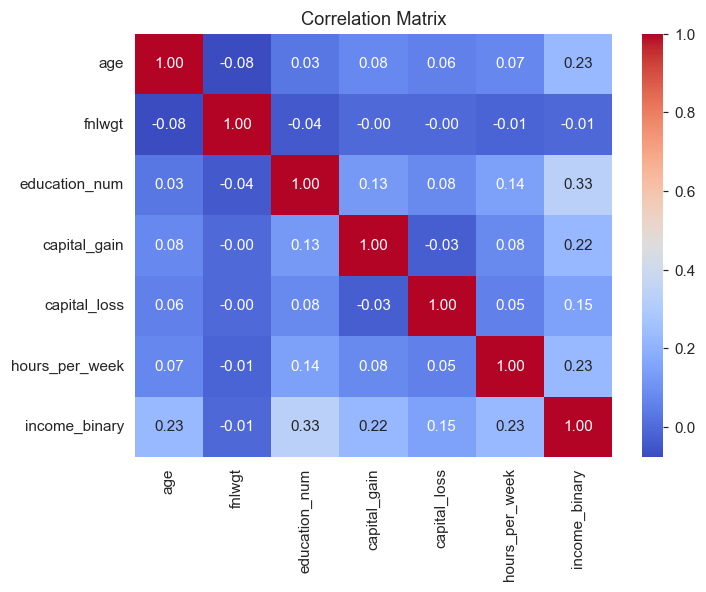

income_binary     1.000000
education_num     0.332802
age               0.230144
hours_per_week    0.227664
capital_gain      0.223047
capital_loss      0.147542
fnlwgt           -0.006309
Name: income_binary, dtype: float64

In [85]:
corr = df[num_cols + ["income_binary"]].corr()

plt.figure(figsize=(7,5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

corr["income_binary"].sort_values(ascending=False)


For categorical features, correlation doesn't apply directly -we look at how much the >50K rate varies across categories and back it up with a chi-square test below, which tells us whether a category and income are statistically related.

In [ ]:
from scipy.stats import chi2_contingency

print("Chi-square test: category vs income")
print("-"*45)
for col in cat_cols:
    table = pd.crosstab(df[col], df["income"])
    chi2, p, dof, expected = chi2_contingency(table)
    print(f"{col:16s} chi2 = {chi2:9.1f}   p-value = {p:.2e}")

Chi-square test: category vs income
---------------------------------------------
workclass        chi2 =    1394.4   p-value = 6.34e-297
education        chi2 =    6536.5   p-value = 0.00e+00
marital_status   chi2 =    9797.1   p-value = 0.00e+00
occupation       chi2 =    4627.8   p-value = 0.00e+00
relationship     chi2 =   10070.6   p-value = 0.00e+00
race             chi2 =     487.5   p-value = 3.41e-104
sex              chi2 =    2246.7   p-value = 0.00e+00


Every categorical feature has a p-value far below 0.05, meaning all of them are statistically related to income. But a low p-value alone doesn't tell us *how strongly* — with a dataset this large, even weak effects become 'significant'. The size of the chi2 statistic and the bar chart gaps we saw above are better guides to real-world importance, which is what we use next.

##

## Question 1 — The Three Most Influential Features

Putting together the correlation values, the chi-square results, and the visualizations above:

**1. Marital status **
The bar chart shows married individuals earn >50K at a much higher rate than single or divorced individuals, and it has the largest chi-square statistic of any categorical feature — by a wide margin.

**2. Education level**
This has the highest correlation with income of any numeric feature, and the boxplot clearly shows the >50K group has more years of education on average.

**3. Capital gain**
Most people report capital_gain = 0, but the small group who report a gain is overwhelmingly in the >50K group. It shows up as a strong correlation and a visibly different distribution in the boxplot.

**Honorable mention:** "age" and "hours_per_week" are both moderately correlated with income around (0.23) but consistently weaker than the top three above.

**Why these three, statistically:** all three have the largest correlation coefficients (numeric) or chi-square statistics (categorical) among their respective feature types, and the effect is visible directly in the charts — not just a small statistical blip.


 
 ##

## Question 2 — Scaling from 1,000 Rows to 10 Million Rows

Everything in this notebook works because the whole dataset (49K rows) fits comfortably in memory and every operation (loading, cleaning, plotting) finishes in seconds. At **10 million rows**, several of these assumptions break down.

### Challenges that would arise

- **Memory:** a `pandas` DataFrame of `10Million` size could easily need GBs of RAM. Simple operations like `.describe()` or `groupby()` could crash a normal laptop or make it swap to disk and slow to a crawl.
- **Load time:** reading a single large CSV with `pd.read_csv()` all at once becomes slow, and re-running it every time wastes minutes.
- **Plotting:** a scatter plot or histogram with 10M points is slow to render and mostly unreadable, plotting will hides the actual pattern.
- **Correlation/chi-square on the full data:** still computable, but expensive to repeat interactively, and p-values become almost meaningless at this scale (virtually everything becomes "statistically significant" even for tiny, meaningless effects).
- **Missing value handling:** `.fillna()` with a mode computed on the fly is fine at `49K` rows, at `10M` rows, computing  repeatedly across many notebook re-runs adds up in wasted compute time and resources.
- **Iteration speed:** EDA is inherently exploratory — you re-run cells many times. If each cell takes minutes instead of seconds, then it is a bottleneck.

### How I will redesign the workflow

1. **Work on a sample first.** Do the actual exploring on a random sample of `~50K–500K` rows. Once the analysis is finalized, re-run the same code on the full dataset just once, at the end.
2. **Use a more efficient file format.** Convert the CSV to **Parquet** 
3. **Use out-of-core / distributed tools instead of plain pandas** — e.g. `Dask` or `polars` which parallelizes across cores and can process data larger than RAM in chunks, or `PySpark` if the data lives in a cluster/data warehouse already. These use pandas-like syntax but don't require the whole dataset to fit in memory.
4. **Reduce memory footprint.** Downcast numeric types (`int64` → `int32`, `float64` → `float32`), convert repetitive text columns (like `workclass`, `education`) to `category` dtype instead of raw strings — this alone can cut memory use by more than half.
5. **Chunk the cleaning step.** Instead of loading everything and cleaning in memory, process the file in chunks (`pd.read_csv(..., chunksize=500_000)`), clean each chunk, and write it back out — so peak memory stays low.
6. **Aggregate before plotting.** For visualizations, don't plot 10M raw points — pre-aggregate (e.g. compute counts/means per bucket) and plot the summary, or use tools built for large-scale rendering (e.g. `datashader`).
7. **Push work to a database/warehouse where possible.** For things like `groupby` averages or the chi-square counts, running the aggregation in SQL (e.g. in BigQuery/Redshift/Postgres) is often faster than pulling all 10M rows into Python first.
8. **Cache intermediate results.** Save the cleaned, sampled, and aggregated versions of the data to disk (Parquet) so you're not repeating expensive cleaning/loading steps every time you restart the notebook.

**In short:** the workflow shifts from "load everything into pandas and explore interactively" to "sample for exploration, use columnar storage and chunked/parallel tools for the full run, and pre-aggregate before visualizing.